# EDA 01 · Analiza Zbioru Respiratory Sound Database ICBHI 2017

<div style="background-color: #f8f9fa; border-left: 4px solid #2b6cb0; padding: 12px 16px; margin-bottom: 20px; border-radius: 0 4px 4px 0;">
  <strong>Praca Inżynierska:</strong> -- <br>
  <strong>Autorzy:</strong> Norbert Gwiazda, Mateusz Ciurzyński | <strong>Data:</strong> 2026-09-02<br>
  <strong>Zbiór danych:</strong> Respiratory Sound Database (ICBHI 2017)<br>
  <strong>Cel:</strong> --
</div>

---

## Spis treści
- [1. Kontekst i Charakterystyka Bazy Danych](#1-kontekst-i-charakterystyka-bazy-danych)
- [2. Środowisko i Import Bibliotek](#2-środowisko-i-import-bibliotek)
- [3. Wczytanie danych](#3-wczytanie-danych)
- [4. Analiza jednowymiarowa](#4-analiza-jednowymiarowa)
  - [4.1. Miejsca odsłuchów](#41-miejsca-odsłuchów)
  - [4.2. Użyty sprzęt nagrywający](#42-użyty-sprzęt-nagrywający)
  - [4.3. Przebieg odsłuchów](#43-przebieg-odsłuchów)
  - [4.4. Diagnoza](#44-diagnoza)
  - [4.5 Trzeszczenia i świsty](#45-trzeszczenia-i-świsty)
  - [4.6 Długość cyklu oddechowego](#46-długość-cyklu-oddechowego)
  - [4.7 Średnia energia sygnału](#47-średnia-energia-sygnału)
- [5. Analiza wielowymiarowa](#5-analiza-wielowymiarowa)
  - [5.1. Diagnoza pacjenta a wystepowanie trzeszczeń i świstów](#51-zależność-między-diagnozą-pacjenta-a-występowaniem-trzeszczeń-i-świstów)
  - [5.2. Miejsce badania a występowanie trzeszczeń i świstów](#52-zależność-między-miejscem-badania-a-występowaniem-trzeszczeń-i-świstów)
  - [5.3. Użyte narzędzie nagrywające a wystepowanie trzeszczeń i świstów](#53-zależność-między-użytym-narzędziem-nagrywającym-a-występowaniem-trzeszczeń-i-świstów)
  - [5.4. Średnia energia sygnału a użyte narzędzie nagrywające](#54-zależność-między-średnią-energiąsygnału-a-użytym-narzędziem-nagrywającym)
---

## 1. Kontekst i Charakterystyka Bazy Danych

Zbiór *Respiratory Sound Database* zawiera próbki cykli oddechowych, zebranych niezależnie przez dwa zespoły naukowe z Portugalii i Grecji na przestrzeni kilku: 
- **Zespół portugalski:** *School of Health Sciences* na Uniwersytecie w Aveiro (ESSUA) - nagrania w Laboratorium Badań i Rehabilitacji Oddechowej (**Lab3R**) oraz w Szpitalu Infante D. Pedro w Aveiro.
- **Zespół grecki:** *Arystotelesowski Uniwersytet w Tesalonikach* (AUTH) oraz *Uniwersytet w Coimbrze* (UC) — nagrania w Szpitalu Głównym Papanikolaou w Tesalonikach oraz w Szpitalu Ogólnym w Imathia.

Baza danych zawiera ponad $5,5$ godzin nagrań, zawierających około $6898$ cykli oddechowych. Dane zebrano od $126$ pacjentów. Nazwy plików z nagraniami zawierają metadane określające indeks pacjenta, miejsce badania, sprzęt użyty do badania oraz sposób badania. Dodatkowo zbiór zawiera pliki tekstowe odpowiadające nagraniom określające czy i w którym momencie nagrania występują świsty lub trzaski.

Lokalizacje osłuchu:
- Trachea (Tc) - Tchawica
- Anterior left (Al) - Przód lewy (przednia lewa strona klatki piersiowej)
- Anterior right (Ar) - Przód prawy (przednia prawa strona klatki piersiowej)
- Posterior left (Pl) - Tył lewy (tylna lewa strona klatki piersiowej)
- Posterior right (Pr) - Tył prawy (tylna prawa strona klatki piersiowej)
- Lateral left (Ll) - Bok lewy (boczna lewa strona klatki piersiowej)
- Lateral right (Lr) - Bok prawy (boczna prawa strona klatki piersiowej)

Sprzęt użyty do badania:
- AKG C417L Microphone (AKGC417L), 
- 3M Littmann Classic II SE Stethoscope (LittC2SE), 
- 3M Litmmann 3200 Electronic Stethoscope (Litt3200), 
- WelchAllyn Meditron Master Elite Electronic Stethoscope (Meditron)

Dostępny jest również plik `ICBHI_Challenge_diagnosis.txt` zawierający diagnozę choroby dla każdego pacjenta. Możliwe diagnozy to:
- Zdrowy (Healthy)
- Astma (Asthma)
- Przewlekła Obturacyjna Choroba Płuc (COPD)
- Zakażenie górnych dróg oddechowych (URTI)
- Infekcja dolnych dróg oddechowych (LRTI)
- Rozstrzenie oskrzeli (Bronchiectasis)
- Zapalenie płuc (Pneumonia)
- Zapalenie oskrzelików (Bronchiolitis)


## 2. Środowisko i Import Bibliotek

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.close_figures = True


import os
import warnings
from pathlib import Path

import librosa
import matplotlib.gridspec as gridspec

# Wizualizacja danych
import matplotlib.pyplot as plt

# Przetwarzanie i analiza numeryczna
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
from matplotlib.lines import Line2D
from pyfonts import load_google_font
from pypalettes import load_cmap, load_palette

# Wyciszenie zbędnych ostrzeżeń
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Wczytanie czionek i palet kolorów
dark_two = load_palette("Dark2")
regular = load_google_font("Roboto", weight=400)
medium = load_google_font("Roboto", weight=500)
bold = load_google_font("Roboto", weight=700)
heavy = load_google_font("Roboto", weight=800)

# Ustawienie motywu
sns.set_theme(style="whitegrid")

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


## 3. Wczytanie danych

W pierwszej kolejności przyjrzymy się zawartości folderu zbioru danych

In [2]:
CACHE_DIR = '.cache'
CACHE_FILE = os.path.join(CACHE_DIR, 'icbhi_features.parquet')

os.makedirs(CACHE_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Wczytywanie pamięci podręcznej z {CACHE_FILE}")
    table = pq.read_table(CACHE_FILE)
    df = table.to_pandas()


DATA_PATH = Path('../data/ICBHI_final_database/')
DIAGNOSIS_FILE = DATA_PATH / 'ICBHI_Challenge_diagnosis.txt'

audio_files = list(DATA_PATH.rglob("*.wav"))

print(f"Wszystkich nagrań: {len(audio_files)}")
print("Pierwsze 5 nagrań:")
for f in audio_files[:5]:
    print(f"  - {f.relative_to(DATA_PATH)}")

print("\n\nZawartość pliku metadanych:")
print(*DIAGNOSIS_FILE.read_text().splitlines()[:5], sep="\n")


Wczytywanie pamięci podręcznej z .cache/icbhi_features.parquet
Wszystkich nagrań: 920
Pierwsze 5 nagrań:
  - 163_2b2_Ll_mc_AKGC417L.wav
  - 139_1b1_Pr_sc_Litt3200.wav
  - 157_1b1_Al_sc_Meditron.wav
  - 138_2p2_Lr_mc_AKGC417L.wav
  - 177_2b4_Tc_mc_AKGC417L.wav


Zawartość pliku metadanych:
101	URTI
102	Healthy
103	Asthma
104	COPD
105	URTI


Przetworzenie plików audio może być problematyczne, dlatego załadujemy metadane do ramki pandas, a do samych plików audio umieścimy wskaźnik.

In [3]:
if not os.path.exists(CACHE_FILE):
    annotations = []
    file_metadata = []

    for file in DATA_PATH.iterdir():
        parts = file.stem.split("_")
        if len(parts) != 5:
            continue

        if file.suffix == ".wav":
            file_metadata.append({"patient_id": int(parts[0]),
                                "recording_id": parts[1],
                                "chest_location": parts[2],
                                "acquisition_mode": parts[3],
                                "recording_equipment": parts[4],
                                "filename": file.stem})
        elif file.suffix == ".txt":
            try:
                anno_df = pd.read_csv(
                    file, sep="\t", names=["start", "end", "crackles", "wheezes"]
                )
                anno_df["filename"] = file.stem
                if anno_df is not None:
                    annotations.append(anno_df)
            except Exception as e:
                print(f"Pominięto uszkodzony plik adnotacji {file.name}: {e}")

    df = pd.concat(annotations, ignore_index=True)
    metadata_df = pd.DataFrame(file_metadata)
    patients_df = pd.read_csv(
        DIAGNOSIS_FILE, sep="\t", names=["patient_id", "diagnosis"]
    )
    merged_metadata = pd.merge(
        metadata_df, patients_df, on="patient_id", how="left"
    )
    df = pd.merge(df, merged_metadata, on="filename", how="left")

df.head()

,start,end,crackles,wheezes,filename,patient_id,recording_id,chest_location,acquisition_mode,recording_equipment,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,1.144,3.848,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,...,29.773043,22.290873,26.88925,20.522661,18.780317,14.956727,14.513029,14.221354,14.142164,11.060841
1,3.848,6.786,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,...,29.773043,22.290873,26.88925,20.522661,18.780317,14.956727,14.513029,14.221354,14.142164,11.060841
2,6.786,9.240,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,...,29.773043,22.290873,26.88925,20.522661,18.780317,14.956727,14.513029,14.221354,14.142164,11.060841
3,9.240,11.962,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,...,29.773043,22.290873,26.88925,20.522661,18.780317,14.956727,14.513029,14.221354,14.142164,11.060841
4,11.962,14.716,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,...,29.773043,22.290873,26.88925,20.522661,18.780317,14.956727,14.513029,14.221354,14.142164,11.060841


W ramach wstępnej analizy załadowane zostanie dodatkowo kilka cech wyciągniętych z plików audio.

In [4]:
if not os.path.exists(CACHE_FILE):
    rms_dict = {}
    zcr_dict = {}
    spectral_centroid_dict = {}
    spectral_flatness_dict = {}
    spectral_rolloff_dict = {}
    spectral_bandwidth_dict = {}
    crest_factor = {}
    mfccs_dict = {}

    for filename in df['filename'].unique():
        y, sr = librosa.load(DATA_PATH / f"{filename}.wav" , sr=None)
        rms = np.mean(librosa.feature.rms(y=y))
        zcr_dict[filename] = np.mean(librosa.feature.zero_crossing_rate(y=y))
        rms_dict[filename] = rms

        crest_factor[filename]  = np.max(np.abs(y)) / (rms+ 1e-8)
        mfccs_dict[filename]  = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)

        spectral_centroid_dict[filename]  = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        spectral_bandwidth_dict[filename]  = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        spectral_rolloff_dict[filename]  = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85))
        spectral_flatness_dict[filename]  = np.mean(librosa.feature.spectral_flatness(y=y))

    df['audio_rms'] = df['filename'].map(rms_dict)
    df['audio_zcr'] = df['filename'].map(zcr_dict)
    df['crest_factor'] = df['filename'].map(crest_factor)

    df['spectral_centroid'] = df['filename'].map(spectral_centroid_dict)
    df['spectral_bandwidth'] = df['filename'].map(spectral_bandwidth_dict)
    df['spectral_rolloff'] = df['filename'].map(spectral_rolloff_dict)
    df['spectral_flatness'] = df['filename'].map(spectral_flatness_dict)

    # Mapowanie MFCC do osobnych kolumn (mfcc_1 ... mfcc_13) po filename
    mfcc_matrix = np.array([mfccs_dict[fname] for fname in df['filename']])
    for i in range(13):
        df[f'mfcc_{i+1}'] = mfcc_matrix[:, i]

    table = pa.Table.from_pandas(df)
    pq.write_table(table, CACHE_FILE)
    print(f"Zapisano dane do buforu {CACHE_FILE}")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   start                6898 non-null   float64
 1   end                  6898 non-null   float64
 2   crackles             6898 non-null   int64  
 3   wheezes              6898 non-null   int64  
 4   filename             6898 non-null   str    
 5   patient_id           6898 non-null   int64  
 6   recording_id         6898 non-null   str    
 7   chest_location       6898 non-null   str    
 8   acquisition_mode     6898 non-null   str    
 9   recording_equipment  6898 non-null   str    
 10  diagnosis            6898 non-null   str    
 11  audio_rms            6898 non-null   float32
 12  audio_zcr            6898 non-null   float64
 13  crest_factor         6898 non-null   float32
 14  spectral_centroid    6898 non-null   float64
 15  spectral_bandwidth   6898 non-null   float64
 16 

## 4. Analiza jednowymiarowa

Przygotowany zbiór danych poddamy teraz analizie, zaczynając od analizy kategorii. W ramach niej, przeanalizowana zostanie każda ze zmiennych kategorycznych. Po każdej podsekcji nastąpi zbiorcze podsumowanie wyników badań. W następnej kolejności przeanalizujemy zmienne binarne. Każdorazowo skupimy się na pojedynczej cesze, nie wchodząc w zależności między cechami.

---

### 4.1 Miejsca odsłuchów


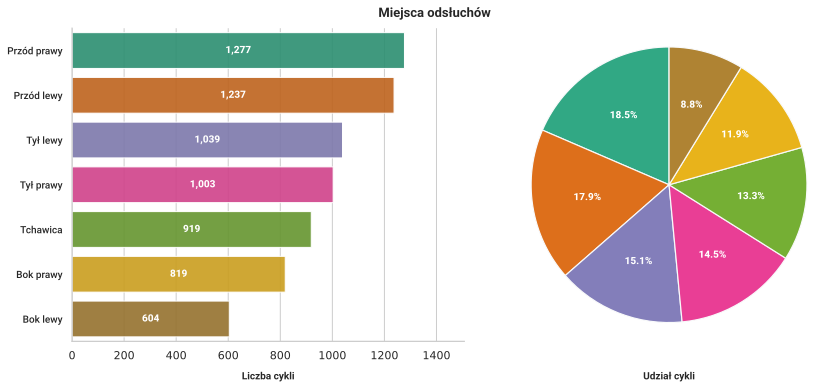

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['chest_location'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:7], strict=True))
labels_map = {
    "Ar": "Przód prawy",
    "Al": "Przód lewy",
    "Tc": "Tchawica",
    "Pl": "Tył lewy",
    "Pr": "Tył prawy",
    "Ll": "Bok lewy",
    "Lr": "Bok prawy"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['chest_location'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Miejsca odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [7]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Miejsca odsłuchów': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Miejsca odsłuchów,Liczebność,Udział (%)
0,Przód prawy,"1,277",18.51%
1,Przód lewy,"1,237",17.93%
2,Tył lewy,"1,039",15.06%
3,Tył prawy,"1,003",14.54%
4,Tchawica,919,13.32%
5,Bok prawy,819,11.87%
6,Bok lewy,604,8.76%


Rozkład miejsc odsłuchow cechuje się niewielkim niezbalansowaniem kategorii, które w przypadku najliczniejszej i najmniej licznej klasy charakteryzuje się ponad dwukrotną liczbą wystąpień jednej klasy względem drugiej. Tak łagodne niezbalansowanie nie wymaga stosowania technik przepróbkowania czy modyfikowania funkcji celu.

---

### 4.2 Użyty sprzęt nagrywający

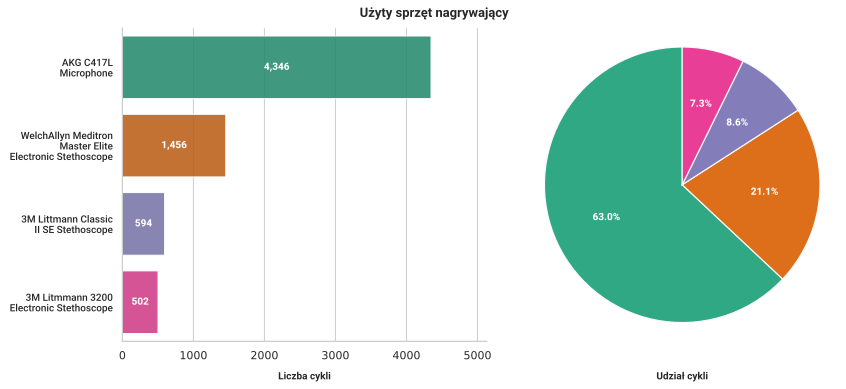

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['recording_equipment'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:4], strict=True))
labels_map = {
    "AKGC417L": "AKG C417L\n Microphone",
    "LittC2SE": "3M Littmann Classic\n II SE Stethoscope",
    "Litt3200": "3M Litmmann 3200\n Electronic Stethoscope",
    "Meditron": "WelchAllyn Meditron\n Master Elite\n Electronic Stethoscope"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Podmienione etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['recording_equipment'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Użyty sprzęt nagrywający ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [9]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Użyty sprzęt nagrywający': [labels_map[label].replace("\n","") for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Użyty sprzęt nagrywający,Liczebność,Udział (%)
0,AKG C417L Microphone,"4,346",63.00%
1,WelchAllyn Meditron Master Elite Electronic St...,"1,456",21.11%
2,3M Littmann Classic II SE Stethoscope,594,8.61%
3,3M Litmmann 3200 Electronic Stethoscope,502,7.28%


Najczęściej występującym stetoskopem w badaniach jest `AKG C417L Microphone` z ponad 3 krotną przewagą w liczbie wystąpień nad drugim `WelchAllyn Meditron Master Elite Electronic Stethoscope`. Niezbalansowanie jest zatem znaczące, a między najmniejszą i największą wynosi $9$-krotność na korzyść tej drugiej. Na dalszym etapie badania niezbędne jest zbadanie, czy wybrany stetoskop ma znaczący wpływ na jakość nagrań. Jeśli miałby, to jest szansa, że niezbalansowanie tej cechy mogłoby pogorszyć skuteczność ewentualnego modelu.

---

### 4.3 Przebieg odsłuchów

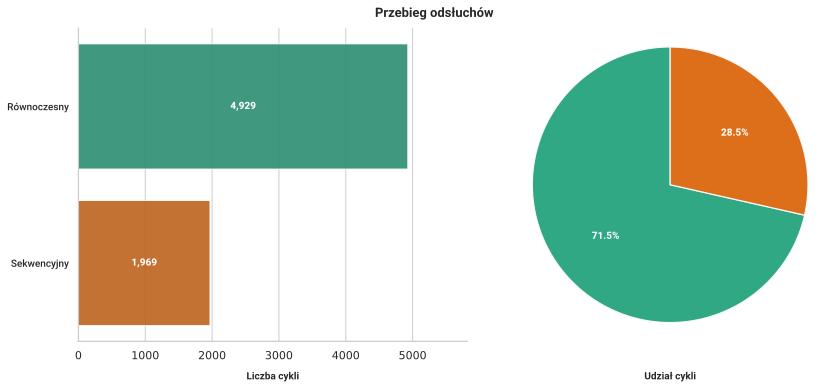

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['acquisition_mode'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:2], strict=True))
labels_map = {
    "mc": "Równoczesny",
    "sc": "Sekwencyjny",
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['acquisition_mode'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Przebieg odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [11]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Przebieg odsłuchów': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Przebieg odsłuchów,Liczebność,Udział (%)
0,Równoczesny,"4,929",71.46%
1,Sekwencyjny,"1,969",28.54%


Nagrania zostały sporządzone w dwóch trybach: sekwencyjnym i równoczesnym. W zależności od trybu, nagrania z różnych miejsc na ciele są zsynchronizowane czasowo lub też rejestrują inne cykle oddechowe. Z powyższych danych wynika, że niemal $3/4$ cykli oddechowych zostało nagranych w trybie równoczesnym, a tylko pozostała $1/4$ w trybie sekwencyjnym. 

Zaobserwowana dysproporcja nie stanowi problemu z punktu widzenia budowy modelu. Głównym celem klasyfikatora będzie detekcja konkretnych patologii akustycznych w obrębie pojedynczych cykli oddechowych, a nie diagnoza pacjenta. W związku z tym, nie ma znaczenia, czy kilka nagrań rejestruje ten sam cykl oddechowy, czy też każdy rejestruje inny. To co ma znaczenie, to czy model w przypadku każdego z tych cykli poprawnie wykryje anomalie oddechowe.

---

### 4.4 Diagnoza pacjentów

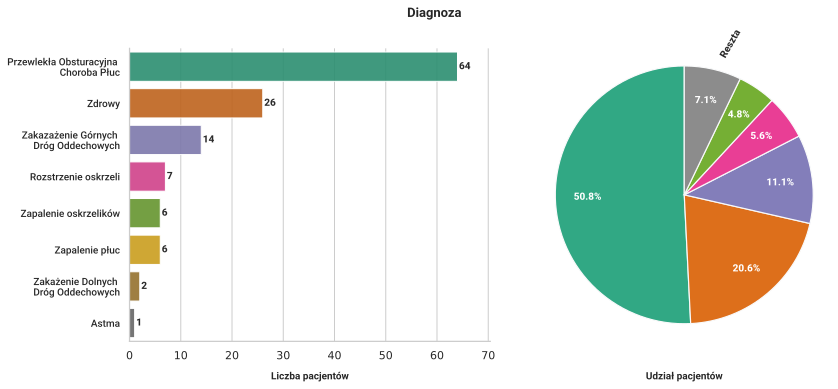

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
df_patients = df[['patient_id','diagnosis']].drop_duplicates().reset_index(drop=True)
counts = df_patients['diagnosis'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:8], strict=True))
labels_map = {
    'COPD': 'Przewlekła Obsturacyjna \nChoroba Płuc',
    'Bronchiectasis': 'Rozstrzenie oskrzeli',
    'Healthy': 'Zdrowy',
    'URTI': 'Zakazażenie Górnych \nDróg Oddechowych',
    'LRTI': 'Zakażenie Dolnych \nDróg Oddechowych',
    'Bronchiolitis': 'Zapalenie oskrzelików',
    'Pneumonia': 'Zapalenie płuc',
    'Asthma': 'Astma'
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="#2b2b2b", label_type="edge", padding=1.5)

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba pacjentów', labelpad=10, font=bold)
ax1.set_xlim(0, df_patients['diagnosis'].value_counts().max() * 1.1)

# Aby zapobiec nagromadzeniu trudnych do odczytania pasków, zgrupujemy małe wartosci w "Reszta"
top_5 = counts.iloc[:5]
others_sum = counts.iloc[5:].sum()
pie_counts = pd.concat([top_5, pd.Series({'Reszta': others_sum})])
pie_color_dict = color_dict.copy()
pie_color_dict['Reszta'] = '#7F7F7F'

# Podpisujemy resztę, aby wykres był zrozumiały
custom_labels = [cat if cat == 'Reszta' else '' for cat in pie_counts.index]

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    pie_counts,
    labels=custom_labels,
    labeldistance=1.2,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    colors=[pie_color_dict[cat] for cat in pie_counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Modyfikacja wyglądu i obrotu etykiety 'Reszta'
for text in texts:
    if text.get_text():
        text.set_rotation(60)
        text.set_font(heavy)
        text.set_fontsize(10)
        text.set_color('#2b2b2b')

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział pacjentów', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Diagnoza ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [13]:
percentages = (counts / len(df_patients)) * 100
pd.DataFrame({'Diagnoza': [labels_map[label].replace("\n","") for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Diagnoza,Liczebność,Udział (%)
0,Przewlekła Obsturacyjna Choroba Płuc,64,50.79%
1,Zdrowy,26,20.63%
2,Zakazażenie Górnych Dróg Oddechowych,14,11.11%
3,Rozstrzenie oskrzeli,7,5.56%
4,Zapalenie oskrzelików,6,4.76%
5,Zapalenie płuc,6,4.76%
6,Zakażenie Dolnych Dróg Oddechowych,2,1.59%
7,Astma,1,0.79%


W przypadku cechy Diagnoza wykresy oraz tabela odnoszą się do liczby pacjentów, a nie do liczby cykli oddechowych. U ponad połowy pacjentów zdiagnozowano Przewlekłą Obturacyjną Chorobę Płuc, natomiast nieco ponad $1/5$ osób zakwalifikowano jako zdrowe. Powyższa cecha jest znacząco niezrównoważona — stosunek liczebności klasy dominującej do najmniej licznej wynosi ponad $64:1$. Podobnie jak w przypadku poprzednich cech, rozkład ten nie stanowi przeszkody metodologicznej, ponieważ głównym celem badawczym jest wykrywanie anomalii w poszczególnych cyklach oddechowych, a nie bezpośrednia diagnoza pacjenta na poziomie globalnym.

---

### 4.5 Trzeszczenia i Świsty

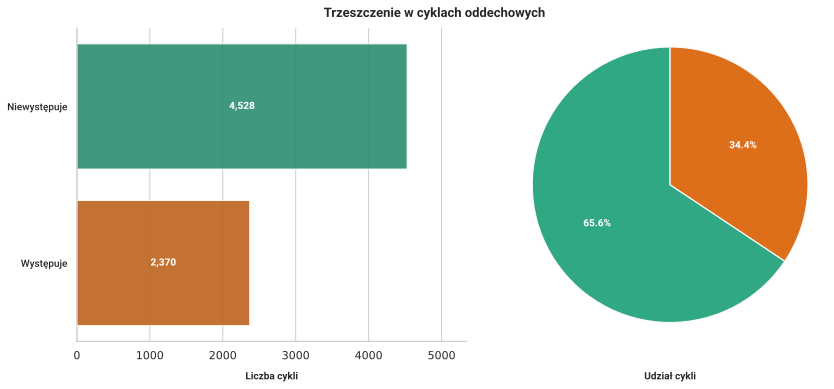

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['crackles'].value_counts().sort_values(ascending=False)
counts.index = counts.index.astype(str)

color_dict = dict(zip(counts.index, dark_two[:2], strict=True))
labels_map = {
    "0": "Niewystępuje",
    "1": "Występuje"

}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['crackles'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Trzeszczenie w cyklach oddechowych ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [15]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Trzeszczenie': ["Niewystępuje", "Występuje"], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Trzeszczenie,Liczebność,Udział (%)
0,Niewystępuje,"4,528",65.64%
1,Występuje,"2,370",34.36%


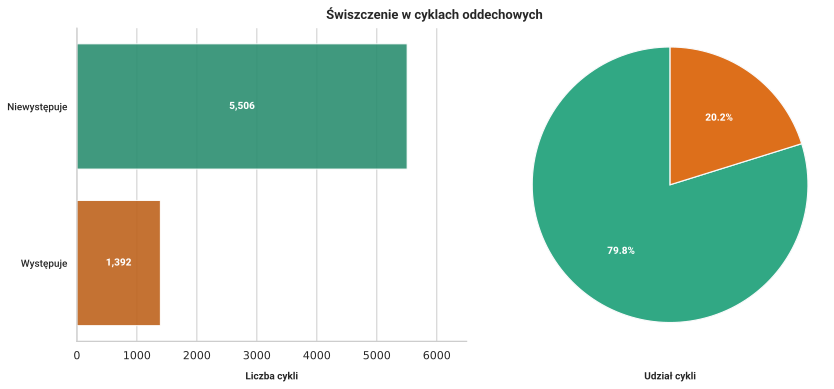

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['wheezes'].value_counts().sort_values(ascending=False)
counts.index = counts.index.astype(str)

color_dict = dict(zip(counts.index, dark_two[:2], strict=True))
labels_map = {
    "0": "Niewystępuje",
    "1": "Występuje"

}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['wheezes'].value_counts().max() * 1.18)


# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Świszczenie w cyklach oddechowych ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [17]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Świszczenie': ["Niewystępuje", "Występuje"], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Świszczenie,Liczebność,Udział (%)
0,Niewystępuje,"5,506",79.82%
1,Występuje,"1,392",20.18%


In [18]:
pd.crosstab(
    df['crackles'].map({0: 'Brak trzeszczeń', 1: 'Trzeszczenia'}),
    df['wheezes'].map({0: 'Brak świstów', 1: 'Świsty'})
)

wheezes,Brak świstów,Świsty
crackles,,
Brak trzeszczeń,3642,886
Trzeszczenia,1864,506


Z powyższych danych wynika, że na $6898$ cykli oddechowych, w ponad $35\%$ występuje trzeszczenie, a w koło $20\%$ świszczenie. W niektórych cyklach oddechowych obie patologie występują jednocześnie. Takich przypadków jest $506$, co stanowi ponad $7\%$ wszystkich cykli oddechowych.

---

### 4.6 Długość cyklu oddechowego

Każda obserwacja w zbiorze ma określony początek cyklu oddechowego w nagraniu oraz jego koniec. Dokonamy analizy czasu trwania cyklów oddechowych.

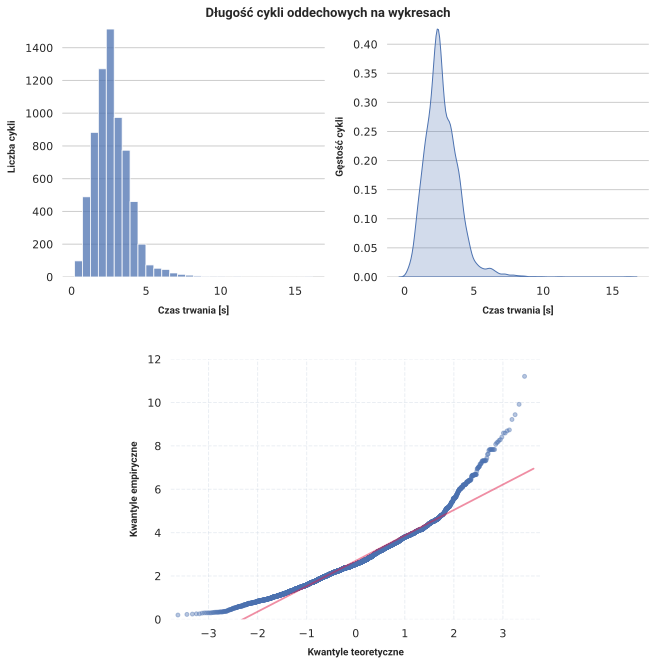

In [19]:
df["duration"] = df["end"] - df["start"]

fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])


ax1.set_xlabel('Czas trwania [s]', labelpad=8, font=bold)
ax1.set_ylabel('Liczba cykli', labelpad=8, font=bold)

sns.histplot(df, x="duration", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df, x="duration", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Czas trwania [s]', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość cykli', labelpad=8, font=bold)


sm.qqplot(
    df["duration"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

ax3.set_ylim(0,12)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Długość cykli oddechowych na wykresach', size=13, font=bold, y=1.01)

plt.show()

In [20]:
table_data = df["duration"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),6898.0000
1,Średnia,2.7005
2,Odchylenie standardowe,1.1725
3,Mediana,2.5370
4,Rozstęp międzykwartylowy (IQR),1.4370
5,Min,0.2000
6,Max,16.1630
7,Skośność (Skewness),1.2152
8,Kurtoza (Kurtosis),4.9907


Z powyższych danych wynika, że cykl oddechowy ma średnią długość $2,7s$. Co ciekawe, niektóre obserwacje opierają się o cykle oddechowe $0,2s$ lub $16s$. Rozkład charakteryzuje się wyraźną prawostronną skośnością oraz bardzo wysoką kurtozą nadmiarową. Oznacza to silną koncentrację cykli wokół mediany i grupy prawy ogon.

Prawidłowy, spoczynkowy cykl oddechowy u dorosłego człowiek trwa zazwyczaj od $3$ do $5$ sekund. Pozostawienie cykli oddechowych o zdecydowanie sprzecznych z fizjologią długościach stanowiłoby poważny metodologiczny błąd. Należy zatem usunąć wartości odstające ze zbioru danych.

---

### 4.7. Średnia energia sygnału

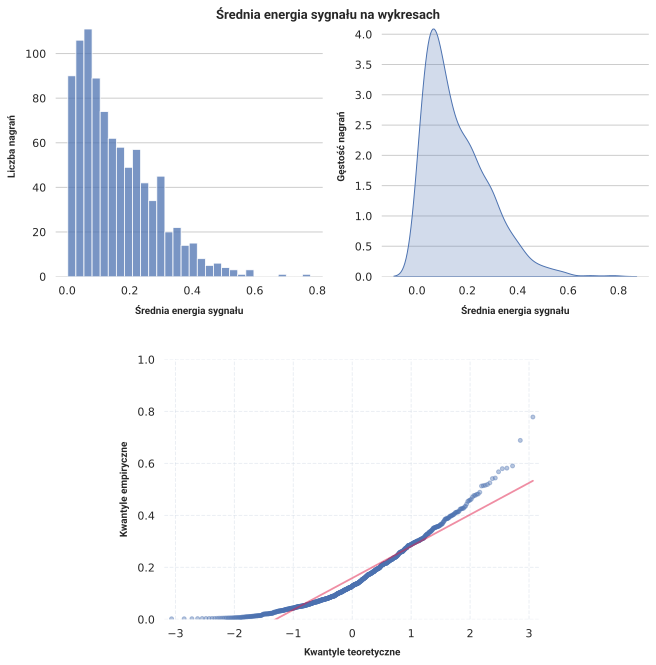

In [21]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])


df_filenames = df.groupby(by="filename").mean(numeric_only=True).reset_index()


ax1.set_xlabel('Średnia energia sygnału', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="audio_rms", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="audio_rms", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Średnia energia sygnału', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["audio_rms"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

ax3.set_ylim(0,1)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Średnia energia sygnału na wykresach', size=13, font=bold, y=1.01)

plt.show()

In [22]:
table_data = df_filenames["audio_rms"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,0.1589
2,Odchylenie standardowe,0.1222
3,Mediana,0.1275
4,Rozstęp międzykwartylowy (IQR),0.1678
5,Min,0.0022
6,Max,0.7787
7,Skośność (Skewness),1.0762
8,Kurtoza (Kurtosis),1.1831


TODO

---
### 4.8 Współczynnik przejść przez zero sygnału

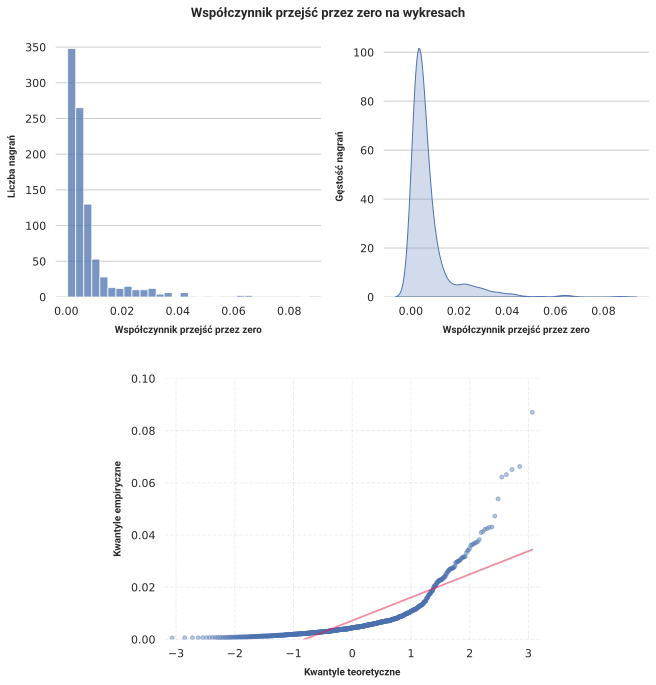

In [23]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])


ax1.set_xlabel('Współczynnik przejść przez zero', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="audio_zcr", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="audio_zcr", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Współczynnik przejść przez zero', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["audio_zcr"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

ax3.set_ylim(0,0.1)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Współczynnik przejść przez zero na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [24]:
table_data = df_filenames["audio_zcr"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,0.0072
2,Odchylenie standardowe,0.0089
3,Mediana,0.0044
4,Rozstęp międzykwartylowy (IQR),0.0050
5,Min,0.0005
6,Max,0.0870
7,Skośność (Skewness),3.5165
8,Kurtoza (Kurtosis),17.0582


TODO

---
### 4.9 Współczynnik szczytu

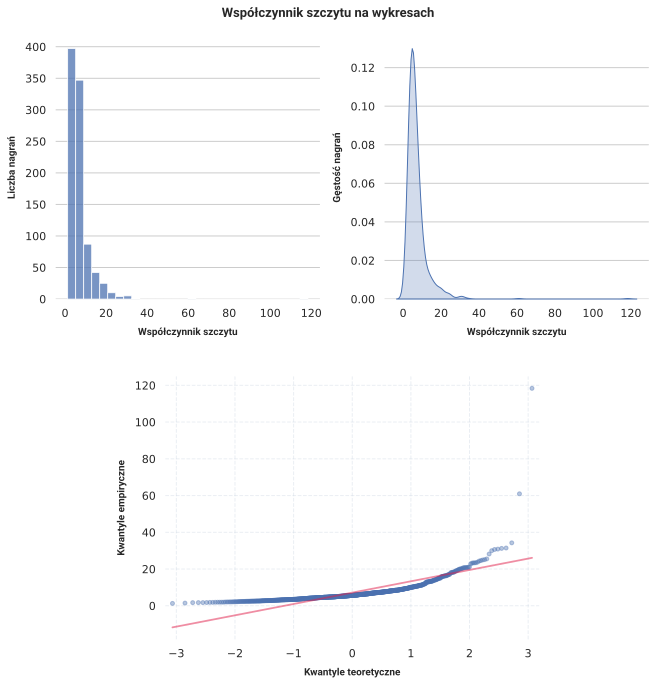

In [25]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])

ax1.set_xlabel('Współczynnik szczytu', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="crest_factor", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="crest_factor", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Współczynnik szczytu', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["crest_factor"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Współczynnik szczytu na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [26]:
table_data = df_filenames["crest_factor"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,7.1593
2,Odchylenie standardowe,6.1771
3,Mediana,5.6309
4,Rozstęp międzykwartylowy (IQR),3.9149
5,Min,1.2843
6,Max,118.3605
7,Skośność (Skewness),8.0034
8,Kurtoza (Kurtosis),120.7114


TODO

---

### 4.10 Środek ciężkości widma

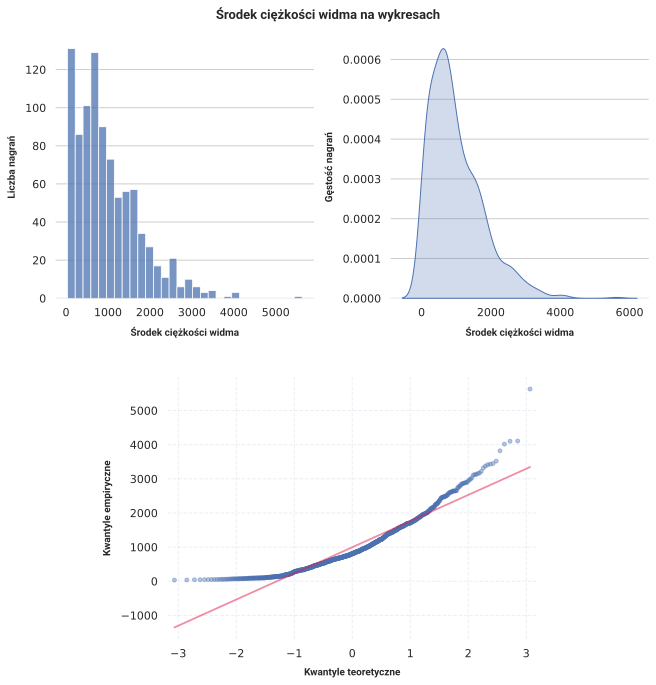

In [27]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])

ax1.set_xlabel('Środek ciężkości widma', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="spectral_centroid", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="spectral_centroid", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Środek ciężkości widma', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["spectral_centroid"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Środek ciężkości widma na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [28]:
table_data = df_filenames["spectral_centroid"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,995.7014
2,Odchylenie standardowe,766.6366
3,Mediana,803.3745
4,Rozstęp międzykwartylowy (IQR),988.9043
5,Min,32.4177
6,Max,5629.1899
7,Skośność (Skewness),1.2817
8,Kurtoza (Kurtosis),2.3247


TODO

---

### 4.11. Szerokość pasma widmowego

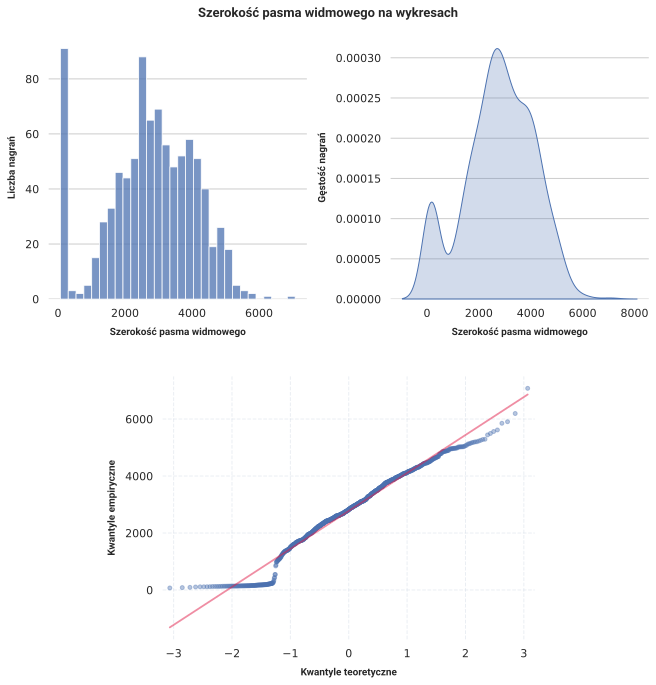

In [29]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])

ax1.set_xlabel('Szerokość pasma widmowego', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="spectral_bandwidth", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="spectral_bandwidth", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Szerokość pasma widmowego', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["spectral_bandwidth"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Szerokość pasma widmowego na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [30]:
table_data = df_filenames["spectral_bandwidth"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,2774.7185
2,Odchylenie standardowe,1333.7613
3,Mediana,2826.6241
4,Rozstęp międzykwartylowy (IQR),1822.0101
5,Min,71.8569
6,Max,7077.9822
7,Skośność (Skewness),-0.2831
8,Kurtoza (Kurtosis),-0.3476


TODO

---

### 4.12. Częstotliwość spadowa widma

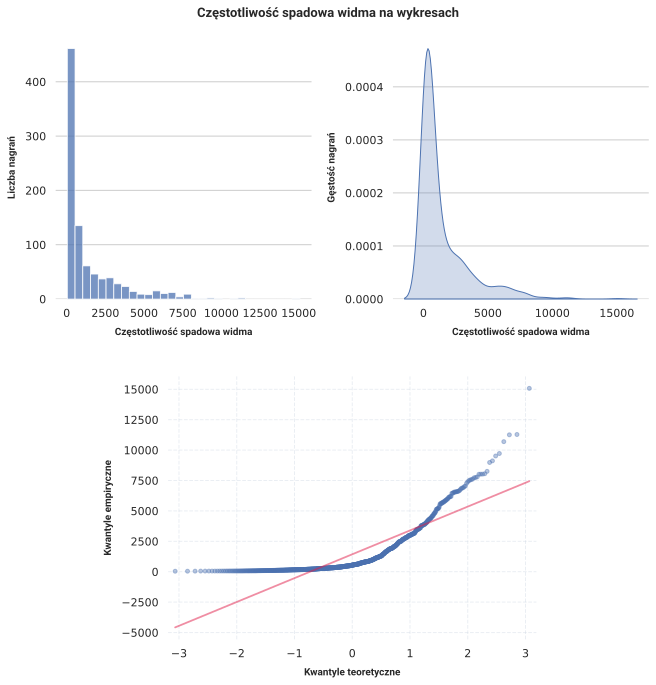

In [31]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])

ax1.set_xlabel('Częstotliwość spadowa widma', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="spectral_rolloff", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="spectral_rolloff", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Częstotliwość spadowa widma', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["spectral_rolloff"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Częstotliwość spadowa widma na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [32]:
table_data = df_filenames["spectral_rolloff"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,1434.7282
2,Odchylenie standardowe,1961.4725
3,Mediana,538.2738
4,Rozstęp międzykwartylowy (IQR),1694.4338
5,Min,40.2016
6,Max,15077.1539
7,Skośność (Skewness),2.2878
8,Kurtoza (Kurtosis),6.2549


TODO

---

### 4.13. Płaskość widma

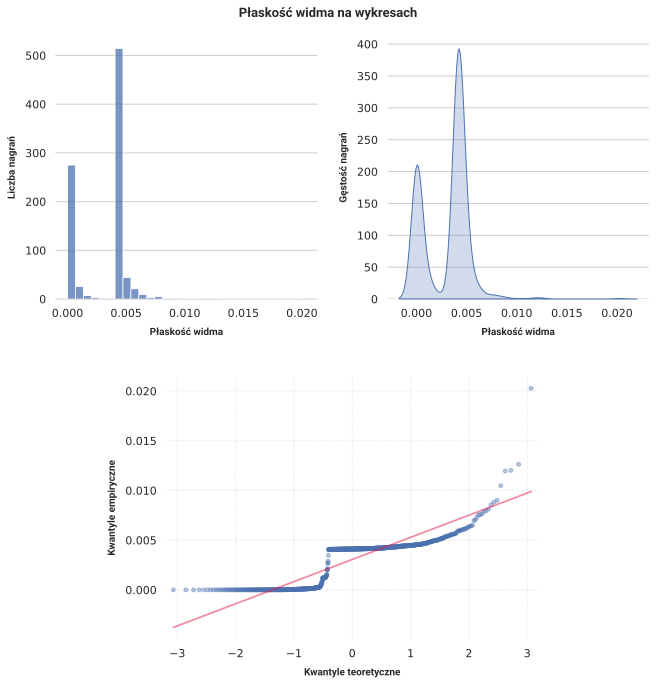

In [33]:
fig = plt.figure(figsize=(9, 9), dpi=150, constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1, 1], hspace=0.12, wspace=0.1)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 1:5])

ax1.set_xlabel('Płaskość widma', labelpad=8, font=bold)
ax1.set_ylabel('Liczba nagrań', labelpad=8, font=bold)

sns.histplot(df_filenames, x="spectral_flatness", ax=ax1, bins=30)
ax1.xaxis.grid(False)

sns.kdeplot(df_filenames, x="spectral_flatness", ax=ax2, fill=True)
ax2.xaxis.grid(False)
ax2.set_xlabel('Płaskość widma', labelpad=8, font=bold)
ax2.set_ylabel('Gęstość nagrań', labelpad=8, font=bold)


sm.qqplot(
    df_filenames["spectral_flatness"], line='s', ax=ax3,
    alpha=0.4, markersize=4
)

qq_line = ax3.get_lines()[1]
qq_line.set_color("#e11d48")
qq_line.set_linewidth(1.8)
qq_line.set_linestyle("-")
qq_line.set_alpha(0.5)

ax3.grid(True, axis='both', linestyle='--', alpha=0.4, color='#cbd5e1')
ax3.set_xlabel('Kwantyle teoretyczne', labelpad=8, font=bold)
ax3.set_ylabel('Kwantyle empiryczne', labelpad=8, font=bold)

sns.despine(top=True, right=True, bottom=True, left=True, ax=ax1)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax3)


fig.suptitle('Płaskość widma na wykresach', size=13, font=bold, y=1.04)

plt.show()

In [34]:
table_data = df_filenames["spectral_flatness"].dropna()

stats_summary = pd.DataFrame({
    "Metryka": [
        "Liczba próbek (n)",
        "Średnia",
        "Odchylenie standardowe",
        "Mediana",
        "Rozstęp międzykwartylowy (IQR)",
        "Min",
        "Max",
        "Skośność (Skewness)",
        "Kurtoza (Kurtosis)"
    ],
    "Wartość": [
        len(table_data),
        table_data.mean(),
        table_data.std(),
        table_data.median(),
        stats.iqr(table_data),
        table_data.min(),
        table_data.max(),
        stats.skew(table_data),
        stats.kurtosis(table_data)  # Fisher=True (0 dla rozkładu normalnego)
    ]
})

# Zaokrąglenie wartości zmiennoprzecinkowych dla czytelności
stats_summary["Wartość"] = stats_summary["Wartość"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
)

stats_summary

,Metryka,Wartość
0,Liczba próbek (n),920.0000
1,Średnia,0.0031
2,Odchylenie standardowe,0.0022
3,Mediana,0.0041
4,Rozstęp międzykwartylowy (IQR),0.0042
5,Min,0.0000
6,Max,0.0203
7,Skośność (Skewness),0.3552
8,Kurtoza (Kurtosis),3.4015


TODO

---

### 4.14. Współczynniki cepstralne w skali Mela

In [37]:
feature_cols = [c for c in df_filenames.columns if 'mfcc' in c]

metrics = {
    "Liczba próbek": lambda x: x.dropna().count(),
    "Średnia": lambda x: x.dropna().mean(),
    "Odchylenie standardowe": lambda x: x.dropna().std(),
    "Mediana": lambda x: x.dropna().median(),
    "Rozstęp IQR": lambda x: stats.iqr(x.dropna()),
    "Min": lambda x: x.dropna().min(),
    "Max": lambda x: x.dropna().max(),
    "Skośność": lambda x: stats.skew(x.dropna()),
    "Kurtoza": lambda x: stats.kurtosis(x.dropna())
}

data = {}
for col in feature_cols:
    s = df_filenames[col]
    data[col] = [func(s) for func in metrics.values()]

# 4. Utworzenie ramki wyników
stats_summary = pd.DataFrame(data, index=list(metrics.keys()))

# 5. Formatowanie wartości do 4 miejsc po przecinku
stats_summary = stats_summary.map(
    lambda x: f"{x:.4f}" if isinstance(x, (float, int)) and not isinstance(x, bool) else str(x)
)

stats_summary = stats_summary.reset_index().rename(columns={"index": "Metryka"})

stats_summary

,Metryka,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,Liczba próbek,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000
1,Średnia,-392.6958,111.6036,52.9352,34.4419,24.9805,23.5330,19.9584,16.7978,12.8598,10.3690,9.2600,9.4964,8.7040
2,Odchylenie standardowe,97.9678,28.5320,17.9201,13.5462,9.5983,6.9338,6.4009,5.4371,5.4449,5.4572,4.3788,3.4091,3.4742
3,Mediana,-372.2868,109.0001,54.4825,36.6076,25.3411,24.0009,20.2251,17.2097,13.6325,11.3991,9.6936,9.6429,8.6022
4,Rozstęp IQR,125.8830,29.8073,21.2644,14.7414,10.3549,7.5568,7.3522,6.1922,6.4215,5.8108,5.0319,4.1709,4.2450
5,Min,-738.4811,35.1838,-43.6900,-37.7662,-35.2880,-3.6609,-18.7298,-13.3850,-5.9577,-9.7010,-11.6716,-5.7585,-3.9796
6,Max,-185.3947,213.2420,96.1439,70.7815,56.3287,48.1096,40.8932,34.0434,29.2102,23.6939,23.7266,21.5065,27.6595
7,Skośność,-0.9030,0.3881,-0.8812,-0.9422,-0.4566,-0.3203,-0.2588,-0.5091,-0.6264,-0.9228,-0.6381,-0.3260,0.3329
8,Kurtoza,0.5600,0.7812,2.3829,1.9172,2.3538,1.0955,1.9554,1.5239,0.4156,0.8790,1.1811,1.0388,1.6163


TODO

---

## 5. Analiza wielowymiarowa

W tej sekcji przeanalizujemy współzależności między zmiennymi oraz podejmiemy próbę porównania nagrań w zależności od nagrywającego sprzętu i miejsca na ciele.

### 5.1. Zależność między diagnozą pacjenta a występowaniem trzeszczeń i świstów

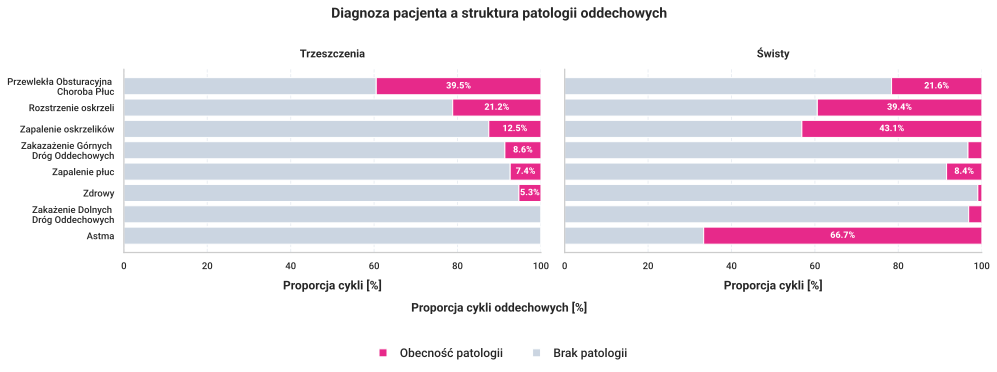

In [ ]:
# 1. Przygotowanie danych dla obu patologii
map_labels = {0: "Nie występuje", 1: "Występuje"}

ct_crackles = pd.crosstab(
    df['diagnosis'],
    df['crackles'].map(map_labels),
    normalize='index'
) * 100

ct_wheezes = pd.crosstab(
    df['diagnosis'],
    df['wheezes'].map(map_labels),
    normalize='index'
) * 100

labels_map = {
    'COPD': 'Przewlekła Obsturacyjna \nChoroba Płuc',
    'Bronchiectasis': 'Rozstrzenie oskrzeli',
    'Healthy': 'Zdrowy',
    'URTI': 'Zakazażenie Górnych \nDróg Oddechowych',
    'LRTI': 'Zakażenie Dolnych \nDróg Oddechowych',
    'Bronchiolitis': 'Zapalenie oskrzelików',
    'Pneumonia': 'Zapalenie płuc',
    'Asthma': 'Astma'
}

# Sortujemy obie tabele według tej samej kolejności (np. według częstotliwości crackles)
order = ct_crackles.sort_values(by="Występuje", ascending=True).index
ct_crackles = ct_crackles.loc[order]
ct_wheezes = ct_wheezes.loc[order]

# 2. Inicjalizacja figury (sharey=True ułatwia porównanie)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True, sharex=True, dpi=200)

color_absent = "#cbd5e1"
color_present = dark_two[3]

ax1.barh(ct_crackles.index, ct_crackles["Nie występuje"], color=color_absent)
ax1.barh(ct_crackles.index, ct_crackles["Występuje"], left=ct_crackles["Nie występuje"], color=color_present)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in ct_crackles.index], fontsize=9.5, font=medium)

for i, (_, row) in enumerate(ct_crackles.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax1.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax1.set_title('Trzeszczenia', pad=12, fontproperties=bold, fontsize=11)
ax1.set_xlim(0, 100)
ax1.set_xlabel('Proporcja cykli [%]', labelpad=8, fontproperties=bold)
ax1.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax1.yaxis.grid(False)
sns.despine(ax=ax1, top=True, right=True)

bars_absent = ax2.barh(ct_wheezes.index, ct_wheezes["Nie występuje"], color=color_absent, label='Brak patologii')
bars_present = ax2.barh(ct_wheezes.index, ct_wheezes["Występuje"], left=ct_wheezes["Nie występuje"], color=color_present, label='Obecność patologii')

for i, (_, row) in enumerate(ct_wheezes.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax2.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax2.set_title('Świsty', pad=12, fontproperties=bold, fontsize=11)
ax2.set_xlim(0, 100)
ax2.set_xlabel('Proporcja cykli [%]', labelpad=8, fontproperties=bold)
ax2.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax2.yaxis.grid(False)
sns.despine(ax=ax2, top=True, right=True)

# Formatowanie ticków dla obu osi
for ax in [ax1, ax2]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(medium)
        label.set_fontsize(9.5)

# 3. Wspólna legenda po prawej stronie
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Obecność patologii',
           markerfacecolor=color_present, markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Brak patologii',
           markerfacecolor=color_absent, markersize=8)
]

fig.supxlabel('Proporcja cykli oddechowych [%]', fontproperties=bold, y=0.05)
fig.suptitle('Diagnoza pacjenta a struktura patologii oddechowych', x=0.5, y=1, fontproperties=bold, fontsize=14)

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    prop=medium,
    handletextpad=0.4,
    columnspacing=1.8
)

plt.tight_layout()
plt.show()

### 5.2. Zależność między miejscem badania, a występowaniem trzeszczeń i świstów

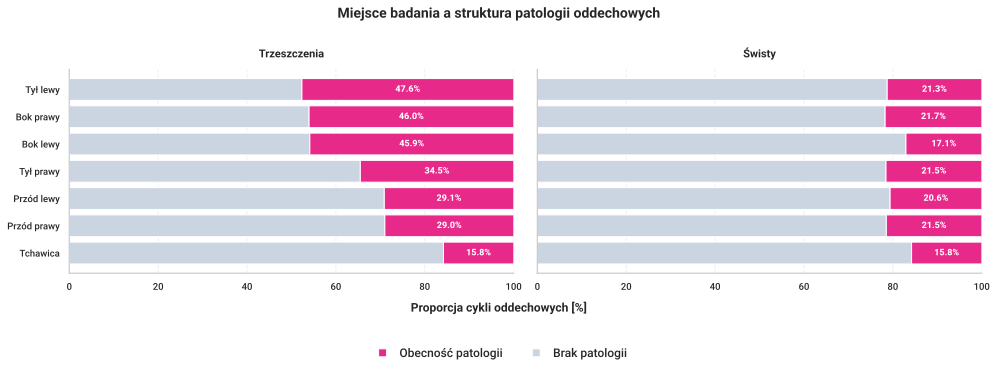

In [ ]:
# 1. Przygotowanie danych dla obu patologii
map_labels = {0: "Nie występuje", 1: "Występuje"}

ct_crackles = pd.crosstab(
    df['chest_location'],
    df['crackles'].map(map_labels),
    normalize='index'
) * 100

ct_wheezes = pd.crosstab(
    df['chest_location'],
    df['wheezes'].map(map_labels),
    normalize='index'
) * 100

labels_map = {
    "Ar": "Przód prawy",
    "Al": "Przód lewy",
    "Tc": "Tchawica",
    "Pl": "Tył lewy",
    "Pr": "Tył prawy",
    "Ll": "Bok lewy",
    "Lr": "Bok prawy"
}

# Sortujemy obie tabele według tej samej kolejności (np. według częstotliwości crackles)
order = ct_crackles.sort_values(by="Występuje", ascending=True).index
ct_crackles = ct_crackles.loc[order]
ct_wheezes = ct_wheezes.loc[order]

# 2. Inicjalizacja figury (sharey=True ułatwia porównanie)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True, sharex=True, dpi=200)

color_absent = "#cbd5e1"
color_present = dark_two[3]

ax1.barh(ct_crackles.index, ct_crackles["Nie występuje"], color=color_absent)
ax1.barh(ct_crackles.index, ct_crackles["Występuje"], left=ct_crackles["Nie występuje"], color=color_present)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in ct_crackles.index], fontsize=9.5, font=medium)

for i, (_, row) in enumerate(ct_crackles.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax1.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax1.set_title('Trzeszczenia', pad=12, fontproperties=bold, fontsize=11)
ax1.set_xlim(0, 100)
ax1.set_ylabel('')
ax1.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax1.yaxis.grid(False)
sns.despine(ax=ax1, top=True, right=True)

bars_absent = ax2.barh(ct_wheezes.index, ct_wheezes["Nie występuje"], color=color_absent, label='Brak patologii')
bars_present = ax2.barh(ct_wheezes.index, ct_wheezes["Występuje"], left=ct_wheezes["Nie występuje"], color=color_present, label='Obecność patologii')

for i, (_, row) in enumerate(ct_wheezes.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax2.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax2.set_title('Świsty', pad=12, fontproperties=bold, fontsize=11)
ax2.set_xlim(0, 100)
ax2.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax2.yaxis.grid(False)
sns.despine(ax=ax2, top=True, right=True)

# Formatowanie ticków dla obu osi
for ax in [ax1, ax2]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(medium)
        label.set_fontsize(9.5)

# 3. Wspólna legenda po prawej stronie
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Obecność patologii',
           markerfacecolor=color_present, markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Brak patologii',
           markerfacecolor=color_absent, markersize=8)
]


fig.supxlabel('Proporcja cykli oddechowych [%]', fontproperties=bold, y=0.05)
fig.suptitle('Miejsce badania a struktura patologii oddechowych', x=0.5, y=1, fontproperties=bold, fontsize=14)

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    prop=medium,
    handletextpad=0.4,
    columnspacing=1.8
)

plt.tight_layout()
plt.show()

### 5.3. Zależność między użytym narzędziem nagrywającym, a występowaniem trzeszczeń i świstów

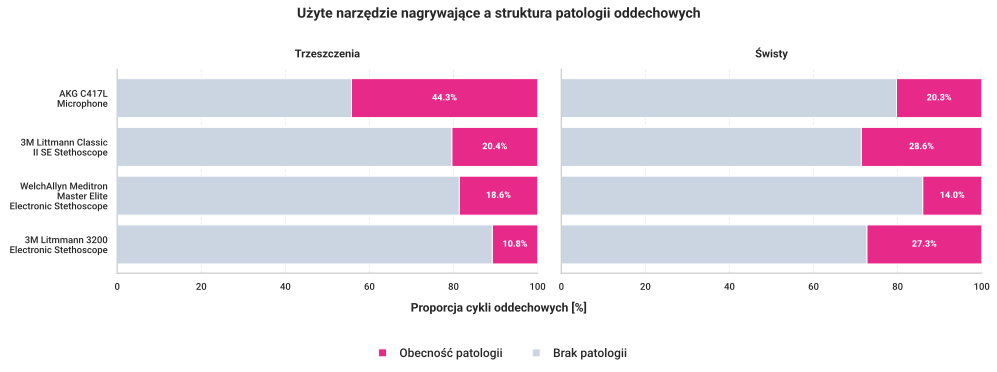

In [ ]:
# 1. Przygotowanie danych dla obu patologii
map_labels = {0: "Nie występuje", 1: "Występuje"}

ct_crackles = pd.crosstab(
    df['recording_equipment'],
    df['crackles'].map(map_labels),
    normalize='index'
) * 100

ct_wheezes = pd.crosstab(
    df['recording_equipment'],
    df['wheezes'].map(map_labels),
    normalize='index'
) * 100

labels_map = {
    "AKGC417L": "AKG C417L\n Microphone",
    "LittC2SE": "3M Littmann Classic\n II SE Stethoscope",
    "Litt3200": "3M Litmmann 3200\n Electronic Stethoscope",
    "Meditron": "WelchAllyn Meditron\n Master Elite\n Electronic Stethoscope"
}

# Sortujemy obie tabele według tej samej kolejności (np. według częstotliwości crackles)
order = ct_crackles.sort_values(by="Występuje", ascending=True).index
ct_crackles = ct_crackles.loc[order]
ct_wheezes = ct_wheezes.loc[order]

# 2. Inicjalizacja figury (sharey=True ułatwia porównanie)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True, sharex=True, dpi=200)

color_absent = "#cbd5e1"
color_present = dark_two[3]

ax1.barh(ct_crackles.index, ct_crackles["Nie występuje"], color=color_absent)
ax1.barh(ct_crackles.index, ct_crackles["Występuje"], left=ct_crackles["Nie występuje"], color=color_present)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in ct_crackles.index], fontsize=9.5, font=medium)

for i, (_, row) in enumerate(ct_crackles.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax1.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax1.set_title('Trzeszczenia', pad=12, fontproperties=bold, fontsize=11)
ax1.set_xlim(0, 100)
ax1.set_ylabel('')
ax1.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax1.yaxis.grid(False)
sns.despine(ax=ax1, top=True, right=True)

bars_absent = ax2.barh(ct_wheezes.index, ct_wheezes["Nie występuje"], color=color_absent, label='Brak patologii')
bars_present = ax2.barh(ct_wheezes.index, ct_wheezes["Występuje"], left=ct_wheezes["Nie występuje"], color=color_present, label='Obecność patologii')

for i, (_, row) in enumerate(ct_wheezes.iterrows()):
    val = row["Występuje"]
    if val > 5:
        ax2.text(
            100 - (val / 2), i, f"{val:.1f}%",
            va='center', ha='center', color='white',
            fontproperties=heavy, fontsize=9
        )

ax2.set_title('Świsty', pad=12, fontproperties=bold, fontsize=11)
ax2.set_xlim(0, 100)
ax2.grid(True, axis='x', linestyle='--', alpha=0.4, color='#cbd5e1')
ax2.yaxis.grid(False)
sns.despine(ax=ax2, top=True, right=True)

# Formatowanie ticków dla obu osi
for ax in [ax1, ax2]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(medium)
        label.set_fontsize(9.5)

# 3. Wspólna legenda po prawej stronie
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Obecność patologii',
           markerfacecolor=color_present, markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Brak patologii',
           markerfacecolor=color_absent, markersize=8)
]


fig.supxlabel('Proporcja cykli oddechowych [%]', fontproperties=bold, y=0.05)
fig.suptitle('Użyte narzędzie nagrywające a struktura patologii oddechowych', x=0.5, y=1, fontproperties=bold, fontsize=14)

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    prop=medium,
    handletextpad=0.4,
    columnspacing=1.8
)

plt.tight_layout()
plt.show()

### 5.4 Zależność między średnią energią sygnału a użytym narzędziem nagrywającym

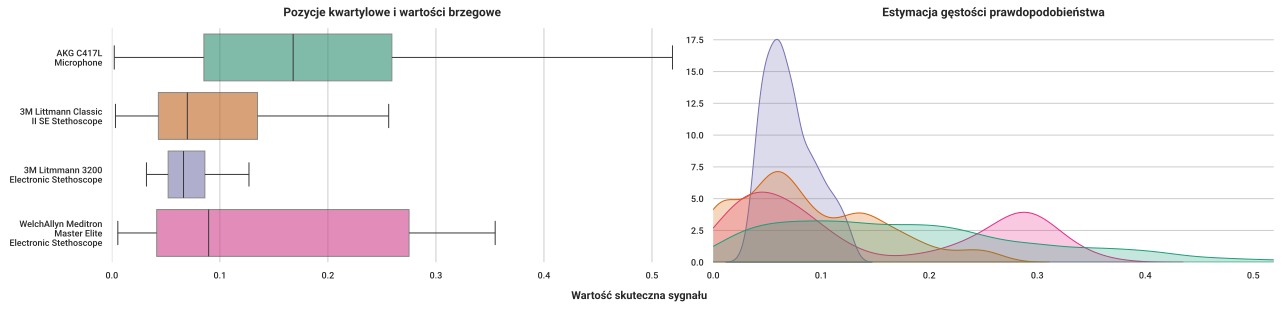

In [ ]:
labels_map = {
    "AKGC417L": "AKG C417L\n Microphone",
    "LittC2SE": "3M Littmann Classic\n II SE Stethoscope",
    "Litt3200": "3M Litmmann 3200\n Electronic Stethoscope",
    "Meditron": "WelchAllyn Meditron\n Master Elite\n Electronic Stethoscope"
}

df['equipment_label'] = df['recording_equipment'].map(labels_map)

# Ustalona kolejność urządzeń dla spójności obu wykresów
equipment_order = [labels_map[k] for k in ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]]

color_dict = dict(zip(equipment_order, dark_two[:4], strict=True))
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(18, 4.5), dpi=150, sharex=True)



sns.boxplot(
    data=df,
    y='equipment_label',
    x='audio_rms',
    order=equipment_order,
    palette=color_dict,
    ax=ax1,
    fliersize=2.5,
    boxprops={"alpha":0.6},
)


ax1.set_title('Pozycje kwartylowe i wartości brzegowe', fontproperties=bold, fontsize=12, pad=12)
ax1.set_ylabel('')
ax1.set_xlabel('')
ax1.yaxis.grid(False)
sns.despine(ax=ax1, top=True, right=True, left=True, bottom=True)

# Formatowanie ticków osi
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontproperties(medium)
    label.set_fontsize(9)

sns.kdeplot(
    data=df,
    x='audio_rms',
    hue='equipment_label',
    hue_order=equipment_order,
    palette=color_dict,
    common_norm=False,
    fill=True,
    legend=False,
    ax=ax2
)

ax2.set_title('Estymacja gęstości prawdopodobieństwa', fontproperties=bold, fontsize=12, pad=12)
ax2.set_ylabel('')
ax2.set_xlabel('')
ax2.set_xlim(0, df['audio_rms'].quantile(0.99))  # Odcięcie skrajnych wartości dla lepszej czytelności
ax2.xaxis.grid(False)
sns.despine(ax=ax2, top=True, right=True, left=True, bottom=True)

# Formatowanie ticków osi
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontproperties(medium)
    label.set_fontsize(9)

fig.supxlabel('Wartość skuteczna sygnału', fontproperties=bold, y=0.05,  fontsize=11)

plt.tight_layout()
plt.show()